<a href="https://colab.research.google.com/github/kanika10-hub/Life_Insurance_Premium_Prediction/blob/main/INSURANCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#!pip install numpy pandas sckit-learn matplotlib seaborn

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

In [5]:
import warnings

In [6]:
warnings.filterwarnings('ignore')

In [7]:
plt.rcParams.update({
    'figure.facecolor':'#FAFAFA',
    'axes.facecolor':'#F4F6F9',
    'axes.grid':True,
    'grid.alpha':0.4,
    'font.size':12,
})

plt.rcParams.update() is used to change Matplotlib's default plotting settings globally. Instead of customizing every graph individually, you set the style once, and every plot you create afterward automatically follows those settings.

In [8]:
sns.set_palette("husl")
print("all libraries imported!")

all libraries imported!


HUSL (now more commonly called HSLuv) is a color space designed to produce bright, evenly spaced, and visually balanced colors.

example-
sns.set_palette("deep")       # Default, balanced colors
sns.set_palette("muted")      # Softer colors
sns.set_palette("bright")     # Bright, vivid colors
sns.set_palette("pastel")     # Light pastel shades
sns.set_palette("dark")       # Darker tones
sns.set_palette("colorblind") # Accessible for color vision deficiencies
sns.set_palette("husl")       # Evenly spaced vibrant colors

In [12]:
df=pd.read_csv('life_insurance.csv')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               597 non-null    object 
 1   bmi               592 non-null    float64
 2   annual_income     595 non-null    object 
 3   sum_assured       597 non-null    float64
 4   policy_term_year  591 non-null    float64
 5   num_dependents    596 non-null    object 
 6   smoker            591 non-null    object 
 7   medical_history   242 non-null    object 
 8   applicant_id      593 non-null    object 
 9   lucky_number      595 non-null    float64
 10  annual_premium    594 non-null    object 
dtypes: float64(4), object(7)
memory usage: 51.7+ KB


df.info() is one of the first commands you should run after loading a dataset.

It gives you a quick summary of the DataFrame so you can understand its structure and identify potential cleaning tasks.

In [14]:
df.describe().round(3)

,bmi,sum_assured,policy_term_year,lucky_number
count,592.000,597.000,591.000,595.000
mean,28.061,1973199.330,17.386,49.444
std,7.760,1492189.503,8.575,29.188
min,11.095,500000.000,5.000,1.000
25%,21.573,750000.000,10.000,24.000
50%,27.407,1500000.000,15.000,48.000
75%,35.133,3000000.000,25.000,74.500
max,44.716,5000000.000,30.000,99.000


In [15]:
missing=df.isnull().sum()

In [16]:
missing_pct=(missing/len(df)*100).round(2)
missing_df=pd.DataFrame({'Missing Count':missing,'Missing %':missing_pct})
missing_df=missing_df[missing_df['Missing Count']>0]
print(missing_df)

                  Missing Count  Missing %
age                           3       0.50
bmi                           8       1.33
annual_income                 5       0.83
sum_assured                   3       0.50
policy_term_year              9       1.50
num_dependents                4       0.67
smoker                        9       1.50
medical_history             358      59.67
applicant_id                  7       1.17
lucky_number                  5       0.83
annual_premium                6       1.00


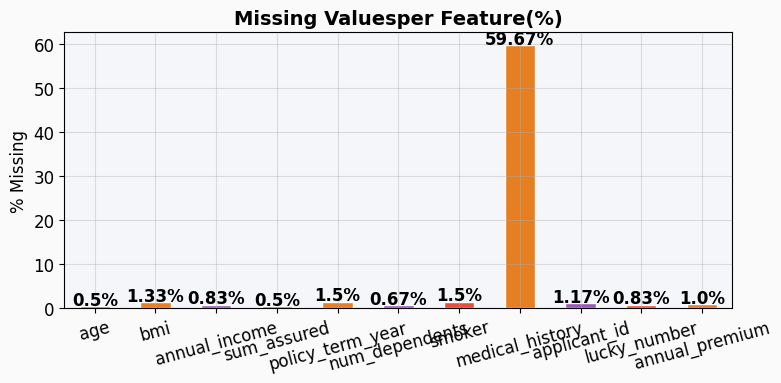

In [17]:
fig,ax=plt.subplots(figsize=(8,4))
missing_df['Missing %'].plot(kind='bar',ax=ax,
                             color=['#E74C3C','#E67E22','#9B59B6'],edgecolor='white')
ax.set_title('Missing Valuesper Feature(%)',fontsize=14,fontweight='bold')
ax.set_ylabel('% Missing'); ax.set_xlabel('')
for i,v in enumerate(missing_df['Missing %']):
  ax.text(i,v+0.3,f'{v}%',ha='center',fontweight='bold')
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig('missing_values.png',dpi=120);
plt.show()

This code creates a bar chart showing the percentage of missing values in each feature (column) and then saves it as an image.

why this matters- an incomplete BMI or medical history could bias premium estimates if ignored or dropped carelessly

The `TypeError` encountered during the box plot generation indicates that some columns intended for numerical operations still contain non-numeric data. Specifically, `age`, `annual_income`, `num_dependents`, and `annual_premium` were identified as `object` type. We need to convert these columns to a proper numeric type, handling any non-numeric entries by coercing them to `NaN`. For `annual_income` and `annual_premium`, which might contain currency symbols or commas, we'll strip these characters before conversion.

In [18]:
# Convert object columns to numeric, coercing errors to NaN
columns_to_convert = ['age', 'annual_income', 'num_dependents', 'annual_premium']
for col in columns_to_convert:
    if col in ['annual_income', 'annual_premium']:
        # Remove non-numeric characters (e.g., '$', ',') before conversion
        # Convert to string first to handle potential mixed types and NaNs gracefully
        df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion for relevant columns:")
display(df[columns_to_convert].info())

Data types after conversion for relevant columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             595 non-null    float64
 1   annual_income   594 non-null    float64
 2   num_dependents  595 non-null    float64
 3   annual_premium  592 non-null    float64
dtypes: float64(4)
memory usage: 18.9 KB


None

Now that the data types are corrected for the numerical columns, we can proceed with generating the box plots for outlier detection. I will also fix the typos (`plt.tght_layout()` to `plt.tight_layout()` and `plt.savfig()` to `plt.savefig()`) and remove the `filterprops` argument, which is not supported by `matplotlib.axes.Axes.boxplot()`.

In [23]:
num_cols = df.select_dtypes(include=['number']).columns
print(num_cols)

Index(['age', 'bmi', 'annual_income', 'sum_assured', 'policy_term_year',
       'num_dependents', 'lucky_number', 'annual_premium'],
      dtype='object')


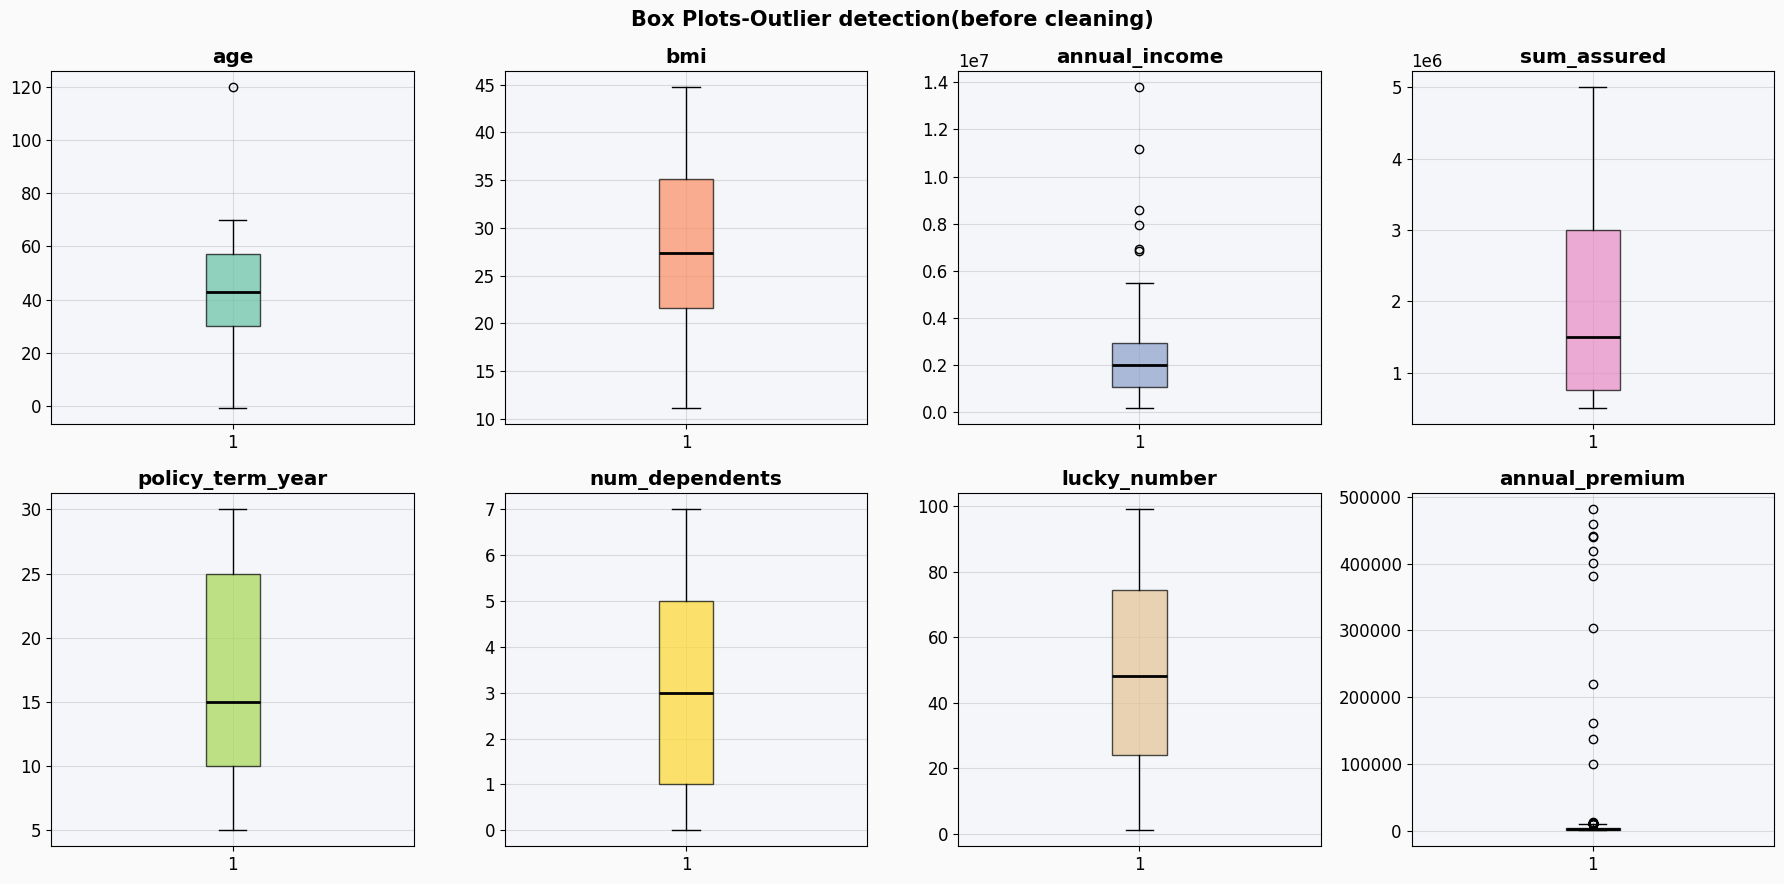

In [24]:
fig,axes=plt.subplots(2,4,figsize=(18,9))
axes=axes.flatten()
fig.suptitle('Box Plots-Outlier detection(before cleaning)',fontsize=15,fontweight='bold')
colors=sns.color_palette("Set2",len(num_cols))
for i,col in enumerate(num_cols):
  axes[i].boxplot(df[col].dropna(),patch_artist=True,
                  boxprops=dict(facecolor=colors[i],alpha=0.7),
                  medianprops=dict(color='black',linewidth=2))
  axes[i].set_title(col,fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_before.png',dpi=120);
plt.show()

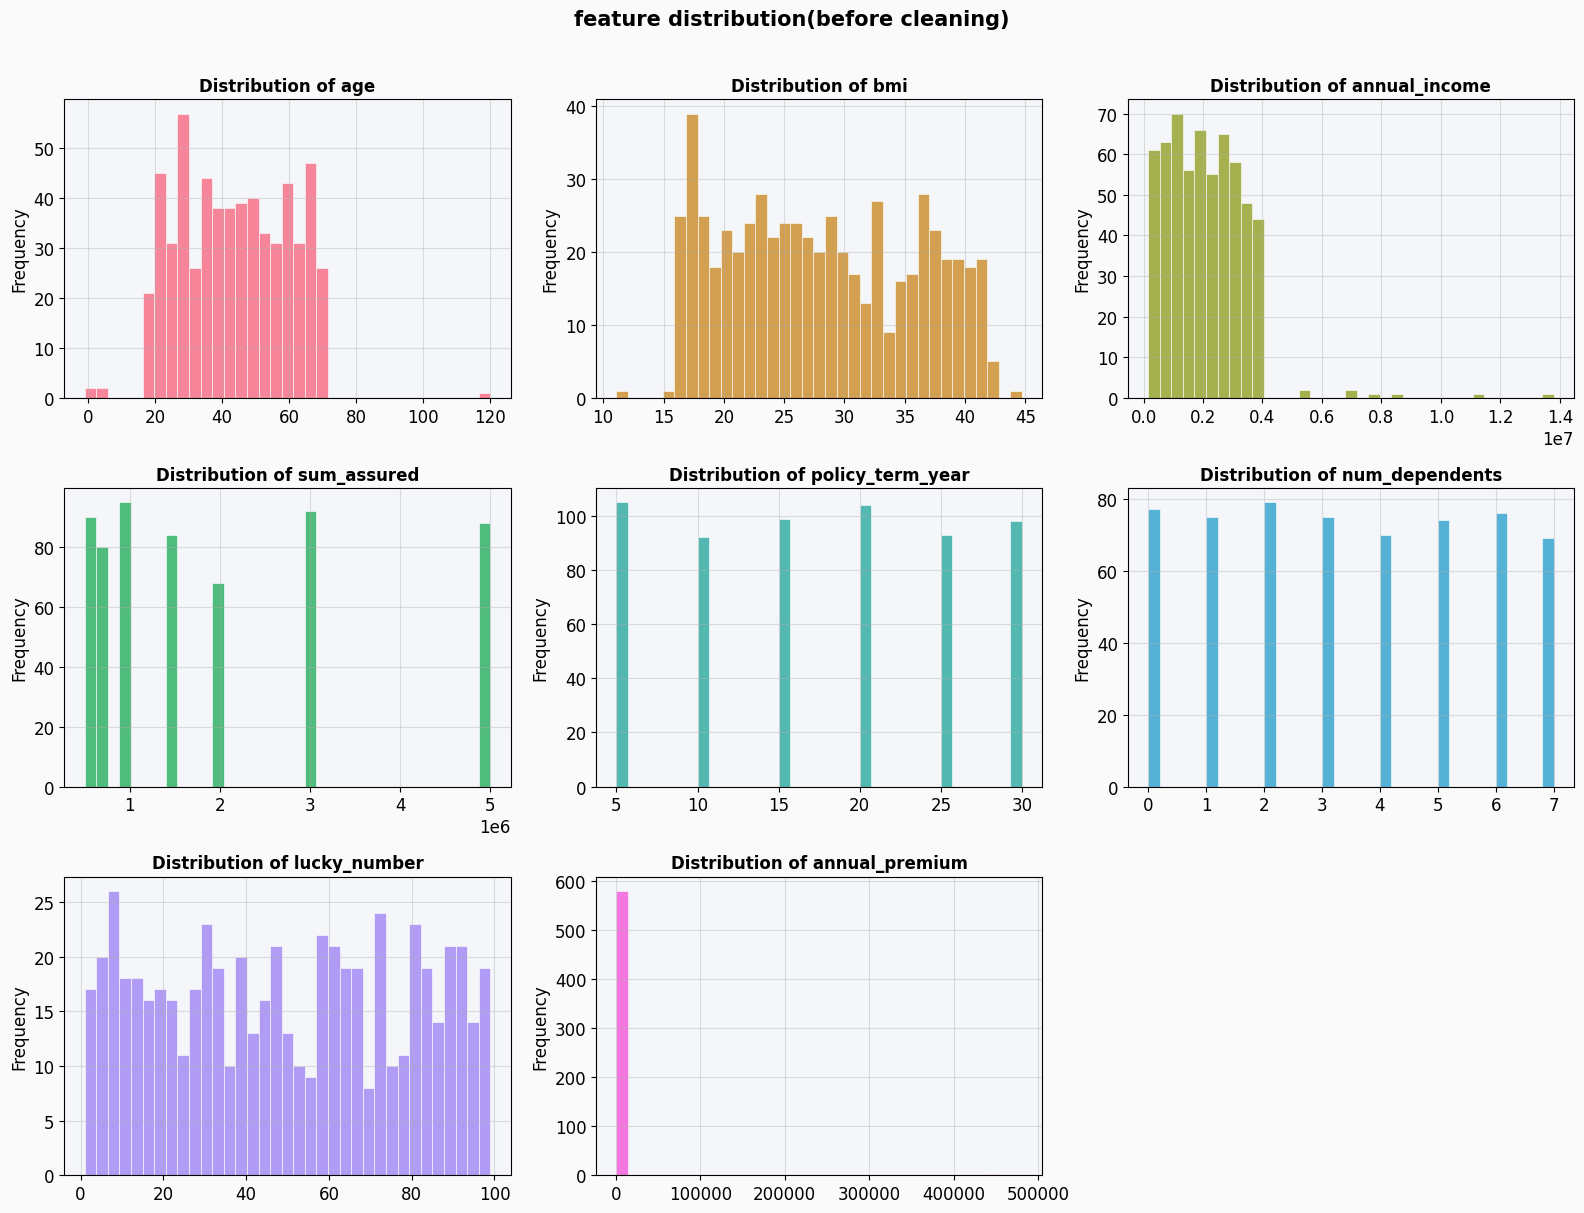

In [25]:
from ipywidgets.widgets.widget_int import Color
num_cols=['age','bmi','annual_income','sum_assured','policy_term_year','num_dependents','lucky_number','annual_premium']
fig,axes=plt.subplots(3,3,figsize=(16,12))
axes=axes.flatten()
fig.suptitle('feature distribution(before cleaning)',fontsize=15,fontweight='bold',y=1.01)
palette=sns.color_palette("husl",len(num_cols))
for i,col in enumerate(num_cols):
  axes[i].hist(df[col].dropna(),bins=35,color=palette[i],edgecolor='white',linewidth=0.5,alpha=0.85)
  axes[i].set_title(f'Distribution of {col}',fontsize=12,fontweight='bold')
  axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('feature_distributions.png',dpi=120)
plt.show()




we need to fix annual income

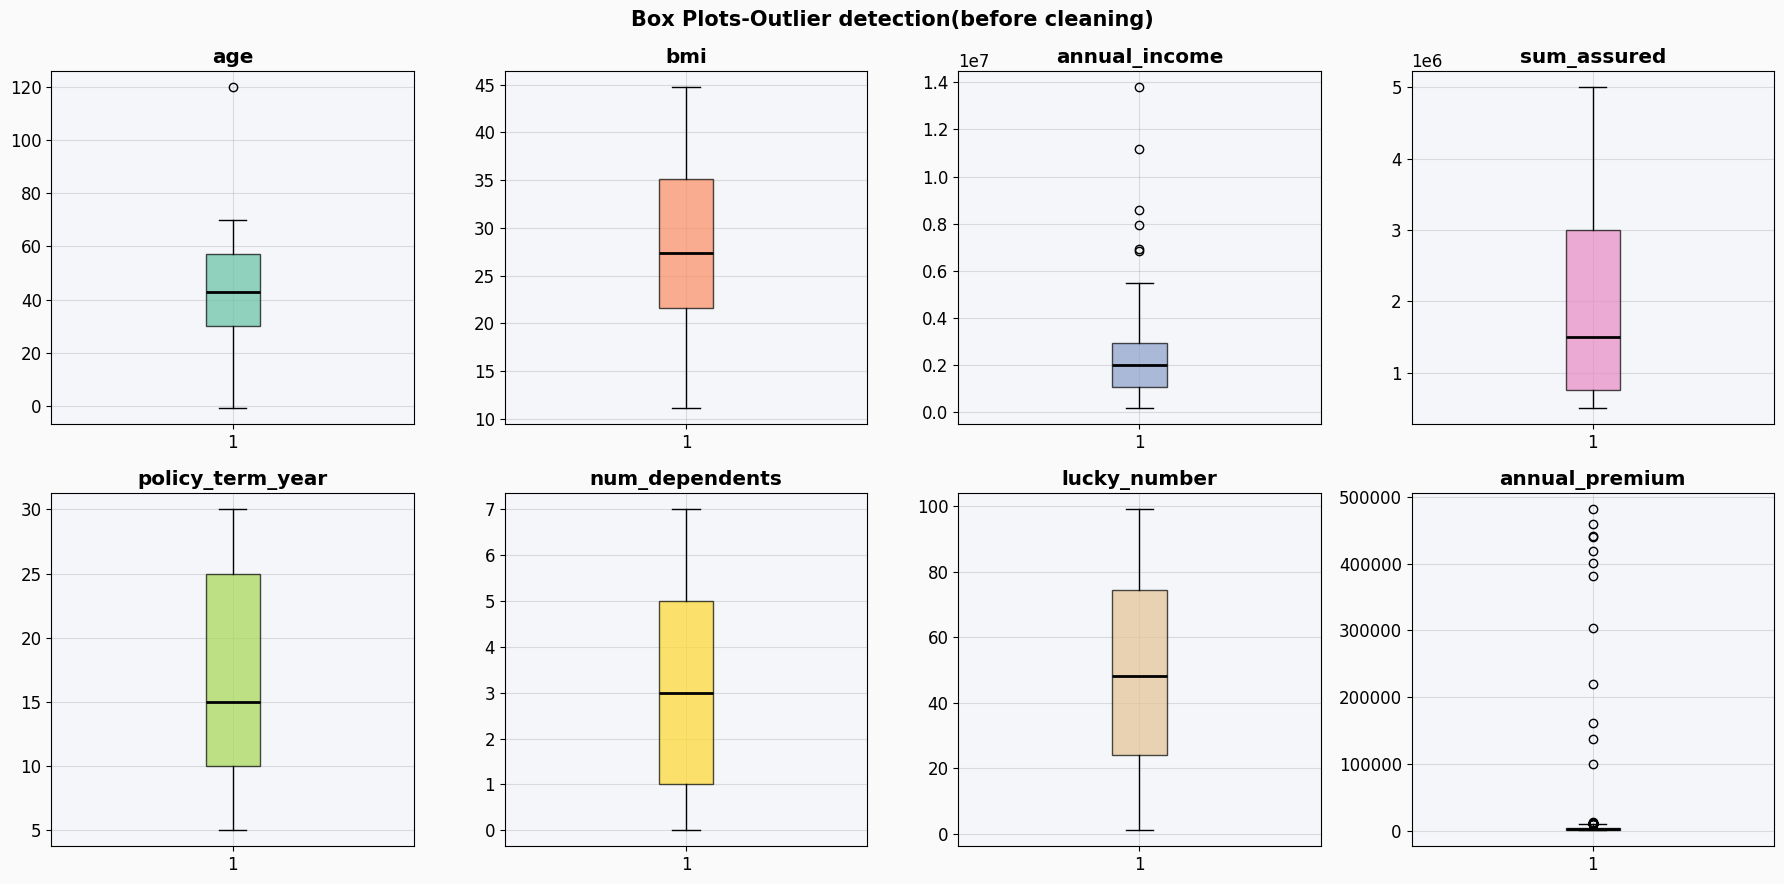

In [26]:
fig,axes=plt.subplots(2,4,figsize=(18,9))
axes=axes.flatten()
fig.suptitle('Box Plots-Outlier detection(before cleaning)',fontsize=15,fontweight='bold')
colors=sns.color_palette("Set2",len(num_cols))
for i,col in enumerate(num_cols):
  axes[i].boxplot(df[col].dropna(),patch_artist=True,
                  boxprops=dict(facecolor=colors[i],alpha=0.7),
                  medianprops=dict(color='black',linewidth=2))
  axes[i].set_title(col,fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_before.png',dpi=120);
plt.show()

TypeError: ufunc 'divide' not supported

usually means that one (or more) of the columns in num_cols is not actually numeric. When boxplot() tries to compute statistics (mean, quartiles, etc.), NumPy attempts to divide string/object values, which causes this error.

In [27]:
print(df[num_cols].dtypes)

age                 float64
bmi                 float64
annual_income       float64
sum_assured         float64
policy_term_year    float64
num_dependents      float64
lucky_number        float64
annual_premium      float64
dtype: object


boxplot() only works with numeric data , so its failing when it reaches one of the object columns

lets check hat in inside those columns


In [28]:
for col in ['age', 'annual_income', 'num_dependents', 'annual_premium']:
    print(f"\n{col}")
    print(df[col].unique()[:10])


age
[38. 50. 21. 20. 70. 22. 41. 49. 66. 56.]

annual_income
[1806009.  510488.  669263. 7924991.  582246. 2746314. 3481869. 3209515.
 2200859. 3492407.]

num_dependents
[ 1.  0.  2.  3.  6.  7. nan  4.  5.]

annual_premium
[6244.802946 2970.        869.048247 1613.741291 3305.454928  824.253893
 1383.75     3352.886623 2220.       2151.010382]


these columns has numbers stored as string , so we convert all the columns safely into int

In [29]:
cols = ['age', 'annual_income', 'num_dependents', 'annual_premium']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

why coerce??
So the '?' in num_dependents won't crash my code.it becomes a missing value (NAN)

In [30]:
print(df.dtypes)

age                 float64
bmi                 float64
annual_income       float64
sum_assured         float64
policy_term_year    float64
num_dependents      float64
smoker               object
medical_history      object
applicant_id         object
lucky_number        float64
annual_premium      float64
dtype: object


In [31]:
for col in ['smoker', 'medical_history', 'applicant_id']:
    print(f"\n{col}")
    print(df[col].unique()[:10])


smoker
['Yes' 'No' 'Y' 'N' ' No ' nan ' Yes ' 'NO' 'YES' ' N ']

medical_history
[nan 'Minor' 'Major' 'Minor ' ' Major' 'major' 'none' 'minor' '?']

applicant_id
['100001' '100002' '100003' '100004' '100005' '100006' '100007' '100008'
 '100009' '100010']


we must convert applicant_id into int as well (right now they are numbers stored as string

In [32]:
cols = ['applicant_id']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [33]:
print(df.dtypes)

age                 float64
bmi                 float64
annual_income       float64
sum_assured         float64
policy_term_year    float64
num_dependents      float64
smoker               object
medical_history      object
applicant_id        float64
lucky_number        float64
annual_premium      float64
dtype: object


PERFECT

AGAIN CHECKING THE CODE (CATEGORICAL FEATURE DISTRIBUTION)

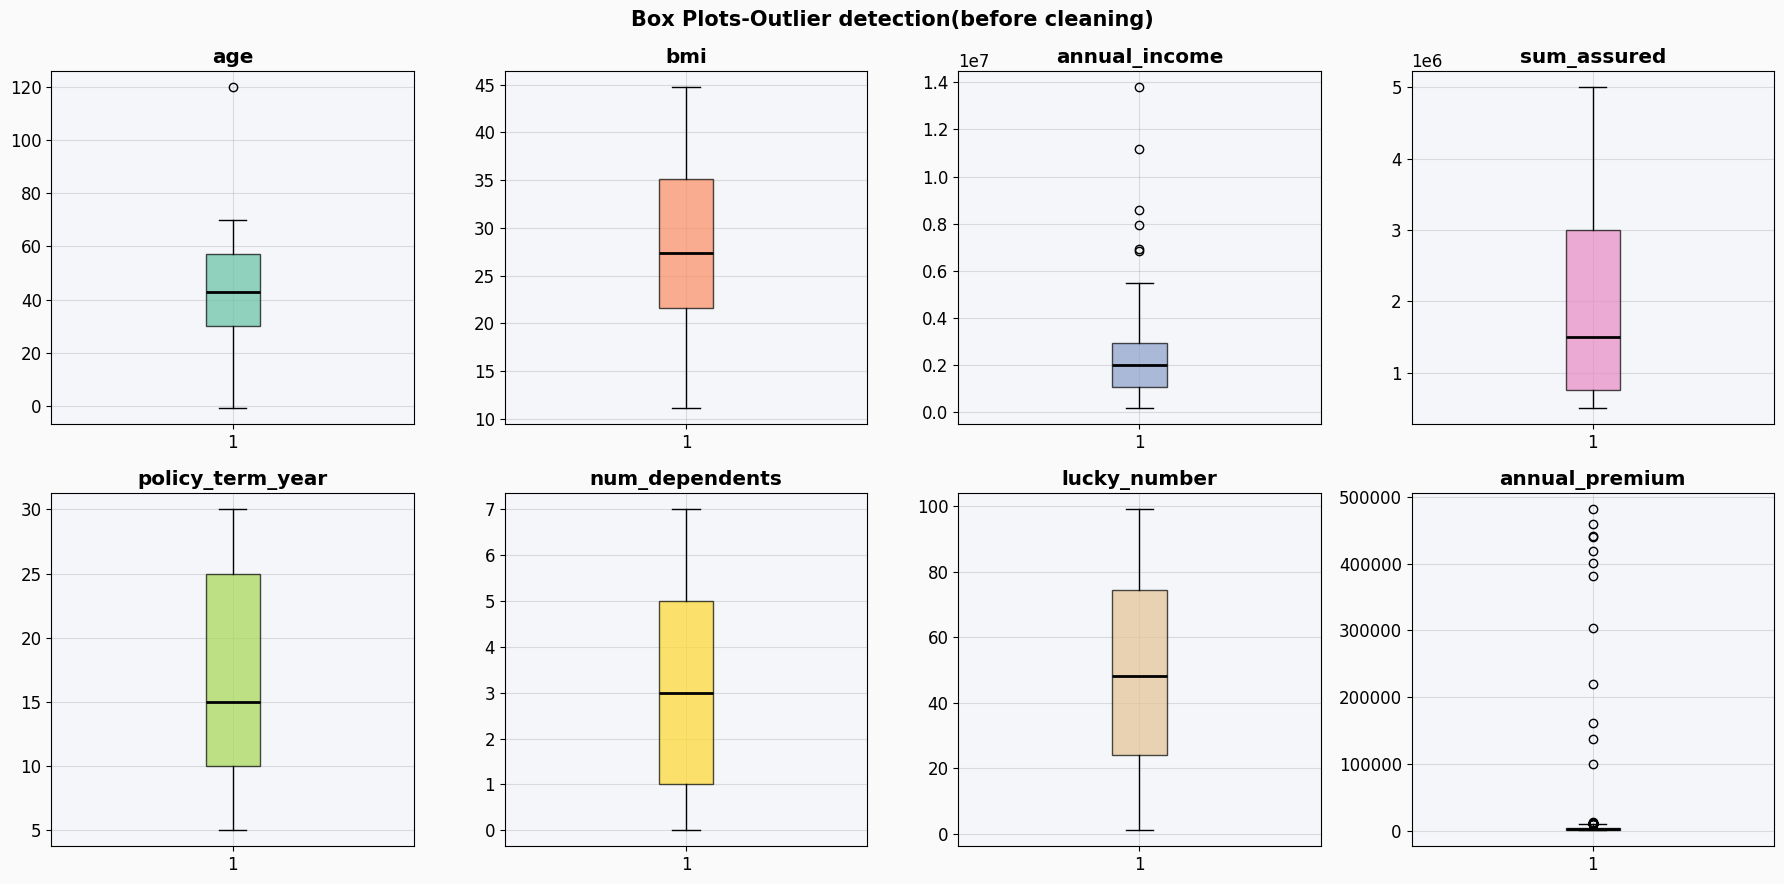

In [34]:
fig,axes=plt.subplots(2,4,figsize=(18,9))
axes=axes.flatten()
fig.suptitle('Box Plots-Outlier detection(before cleaning)',fontsize=15,fontweight='bold')
colors=sns.color_palette("Set2",len(num_cols))
for i,col in enumerate(num_cols):
  axes[i].boxplot(df[col].dropna(),patch_artist=True,
                  boxprops=dict(facecolor=colors[i],alpha=0.7),
                  medianprops=dict(color='black',linewidth=2))
  axes[i].set_title(col,fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_before.png',dpi=120);
plt.show()

This is a very common pattern in exploratory data analysis (EDA): create a grid of subplots and loop through each feature to visualize it.

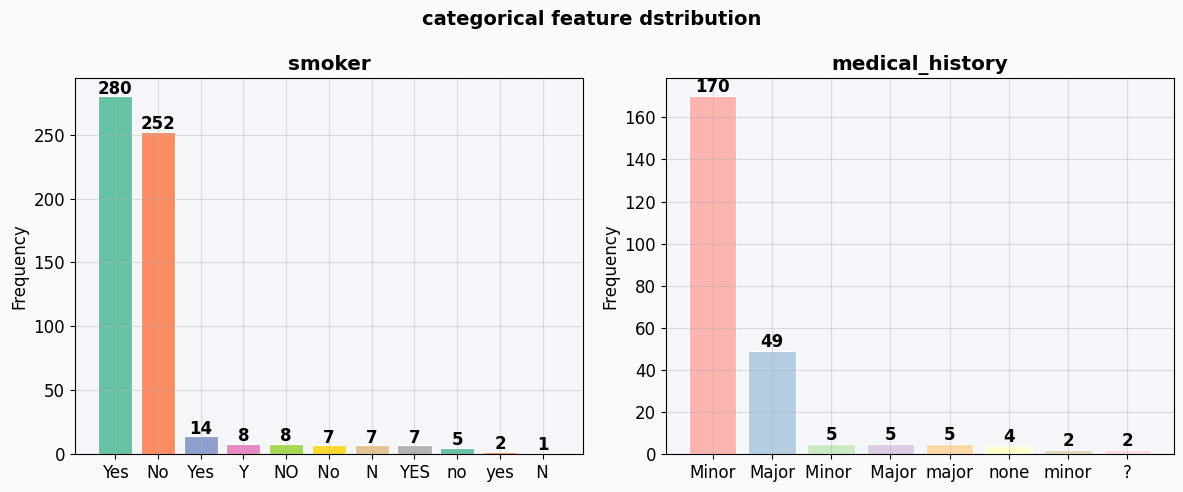

In [35]:
#categorical feature distribution

fig,axes=plt.subplots(1,2,figsize=(12,5))
fig.suptitle('categorical feature dstribution',fontsize=14,fontweight='bold')
for ax,col,pal in zip (axes,['smoker','medical_history'],['Set2','Pastel1']):
  counts=df[col].value_counts()
  bars=ax.bar(counts.index,counts.values,color=sns.color_palette(pal,len(counts)),edgecolor='white',linewidth=0.8)
  ax.set_title(col,fontweight='bold')
  ax.set_ylabel('Frequency')
  for bar,val in zip(bars,counts.values):
    ax.text(bar.get_x()+bar.get_width()/2,val+2,str(val),ha='center',fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_dist.png',dpi=120);
plt.show()

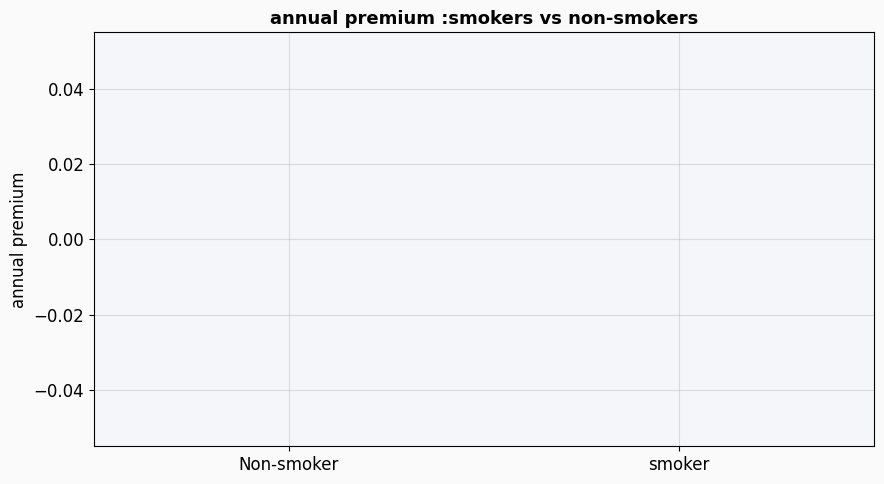

In [36]:
#premium by smoker status (business insight)

fig,ax=plt.subplots(figsize=(9,5))
data_to_plot=[df[df['smoker']=='No']["annual_premium"].values,
              df[df['smoker']=='Yes']['annual_premium'].values
]
bp=ax.boxplot(data_to_plot,patch_artist=True,labels=['Non-smoker','smoker'],
              medianprops=dict(color='black',linewidth=2.5))
bp['boxes'][0].set_facecolor('#2ECC71')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#E74C3C')
bp['boxes'][1].set_alpha(0.6)
ax.set_title('annual premium :smokers vs non-smokers',fontsize=13,fontweight='bold')
ax.set_ylabel('annual premium')
plt.tight_layout()
plt.show()

In [37]:
print(df['smoker'].value_counts(dropna=False))

smoker
Yes      280
No       252
 Yes      14
NaN        9
NO         8
Y          8
N          7
 No        7
YES        7
no         5
yes        2
 N         1
Name: count, dtype: int64


In [38]:
print(len(df[df['smoker'] == 'No']))
print(len(df[df['smoker'] == 'Yes']))

252
280


In [39]:
print(df['annual_premium'].dtype)
print(df['annual_premium'].head())

float64
0    6244.802946
1    2970.000000
2     869.048247
3    1613.741291
4    3305.454928
Name: annual_premium, dtype: float64


In [40]:
print(df['annual_premium'].isna().sum())
print(df['annual_premium'].count())

8
592


In [41]:
non_smoker = df[df['smoker'] == 'No']['annual_premium']
smoker = df[df['smoker'] == 'Yes']['annual_premium']

print(non_smoker.shape)
print(smoker.shape)

print(non_smoker.head())
print(smoker.head())

(252,)
(280,)
2     869.048247
4    3305.454928
5     824.253893
8    2220.000000
9    2151.010382
Name: annual_premium, dtype: float64
0    6244.802946
1    2970.000000
3    1613.741291
6    1383.750000
7    3352.886623
Name: annual_premium, dtype: float64


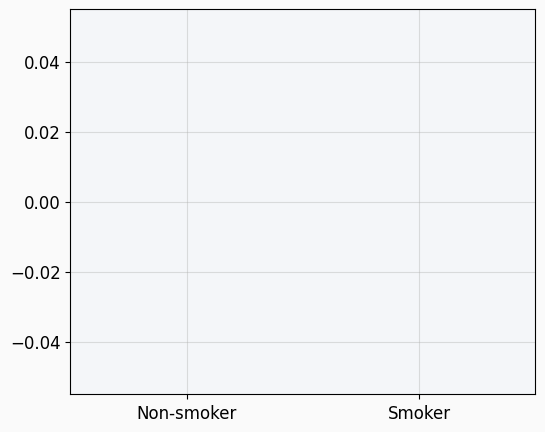

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.boxplot([non_smoker, smoker], tick_labels=['Non-smoker', 'Smoker'])
plt.show()

In [43]:
print(type(non_smoker))
print(type(smoker))

print(non_smoker.shape)
print(smoker.shape)

print(non_smoker[:5])
print(smoker[:5])

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
(252,)
(280,)
2     869.048247
4    3305.454928
5     824.253893
8    2220.000000
9    2151.010382
Name: annual_premium, dtype: float64
0    6244.802946
1    2970.000000
3    1613.741291
6    1383.750000
7    3352.886623
Name: annual_premium, dtype: float64


In [44]:
import matplotlib
print(matplotlib.__version__)

3.10.0


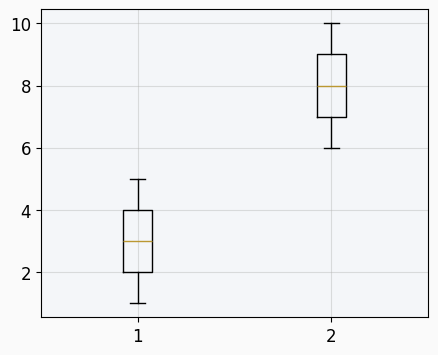

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.boxplot([[1,2,3,4,5], [6,7,8,9,10]])
plt.show()

In [46]:
print(non_smoker.min())
print(non_smoker.max())

print(smoker.min())
print(smoker.max())

525.0
441853.802
793.022805
418140.574


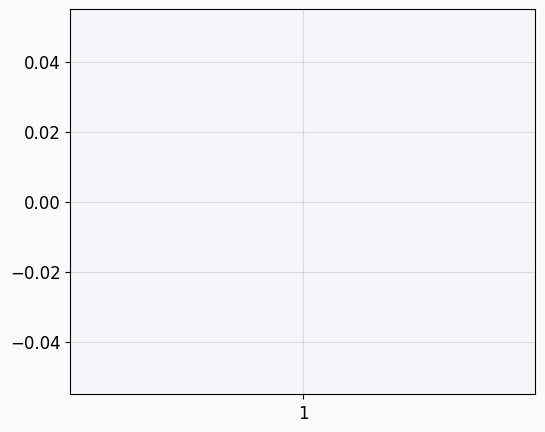

In [47]:
plt.figure(figsize=(6,5))

plt.boxplot(non_smoker)

plt.show()

In [48]:
print(non_smoker.dtype)
print(non_smoker.head())
print(type(non_smoker.iloc[0]))

float64
2     869.048247
4    3305.454928
5     824.253893
8    2220.000000
9    2151.010382
Name: annual_premium, dtype: float64
<class 'numpy.float64'>


In [49]:
import numpy as np

print(np.asarray(non_smoker))
print(np.asarray(non_smoker).shape)

[   869.048247   3305.454928    824.253893   2220.         2151.010382
   1040.         1220.         6750.         2390.505122   1680.
   1240.          667.512261   7750.08253    7300.         2240.
    708.136258   2455.112956   2560.                 nan   3826.212608
   1117.5         621.667502   2960.         3480.         1719.049615
   1409.061389 218935.343      4440.         3270.          655.
   6081.792806   5050.         3310.890398   3960.         1875.
   3705.524715    675.         3540.          525.         6387.838128
   2339.857684    716.612358    688.722269    621.741048   1875.
   1380.         7124.315315   2590.53463     780.         6207.730941
   1534.32405     716.59124    1430.         1490.         7733.914617
   2920.         7929.01088     750.466692    825.         7117.275924
   6017.548142   2551.007984   2160.         4200.          887.149642
    610.         2729.183213   1071.665874   2178.699264 439995.665
   3739.352552   5149.846078           

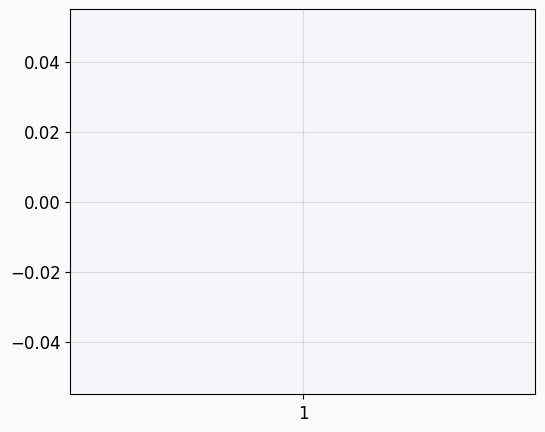

In [50]:
plt.figure(figsize=(6,5))
plt.boxplot(np.asarray(non_smoker))
plt.show()

In [51]:
import pandas as pd
print(pd.options.plotting.backend)

matplotlib


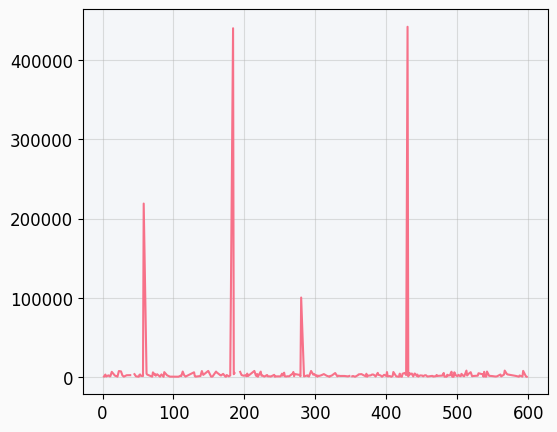

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(non_smoker)
plt.show()

In [53]:
print(non_smoker.index[:10])

Index([2, 4, 5, 8, 9, 10, 11, 13, 17, 18], dtype='int64')


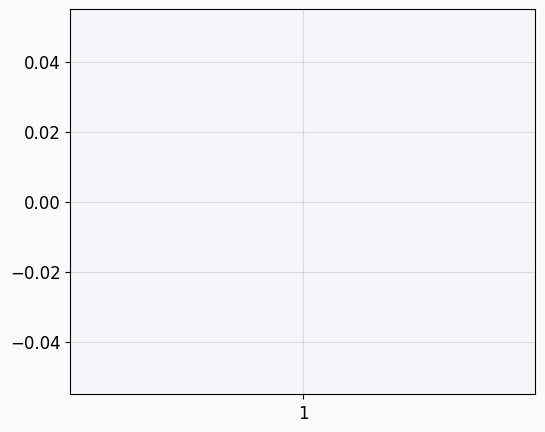

In [54]:
non_smoker_reset = non_smoker.reset_index(drop=True)

plt.figure(figsize=(6,5))
plt.boxplot(non_smoker_reset)
plt.show()

In [55]:
import numpy as np

print(non_smoker.describe())

print("NaN:", np.isnan(non_smoker).sum())
print("Inf:", np.isinf(non_smoker).sum())

print("Min:", non_smoker.min())
print("Max:", non_smoker.max())

count       249.000000
mean       7396.584857
std       41923.347671
min         525.000000
25%        1071.114575
50%        1950.000000
75%        3739.352552
max      441853.802000
Name: annual_premium, dtype: float64
NaN: 3
Inf: 0
Min: 525.0
Max: 441853.802


True


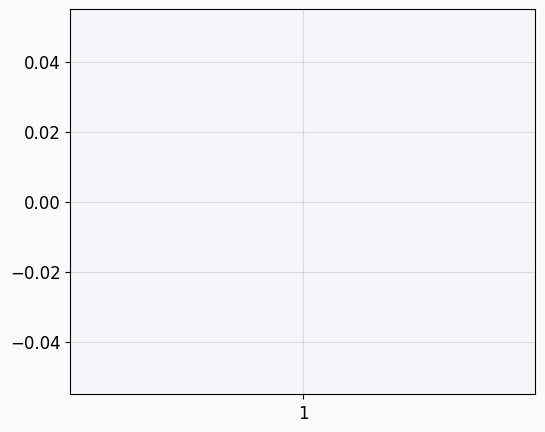

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

ax.boxplot(non_smoker.values.tolist())

print(ax.has_data())

plt.show()

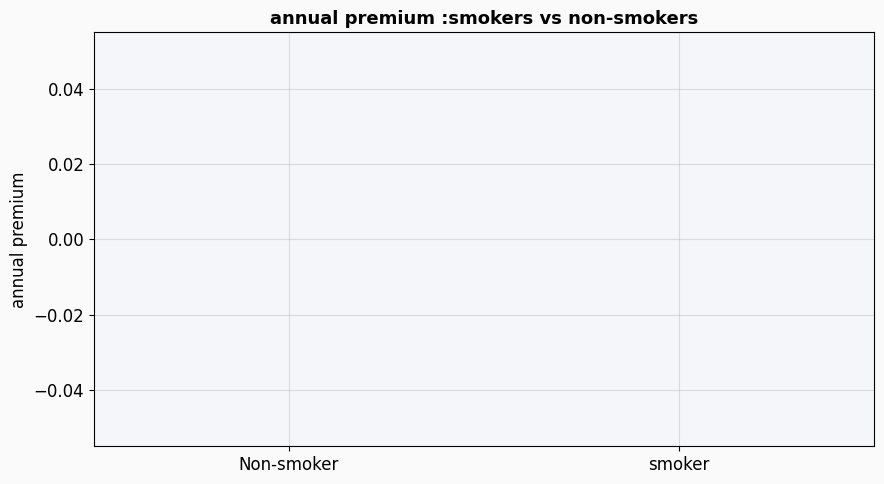

 avg premium-non-smokers: 7,397
 avg premium-smokers: 8,315


In [57]:
#premium by smoker status (business insight)

fig,ax=plt.subplots(figsize=(9,5))
data_to_plot=[df[df['smoker']=='No']["annual_premium"].values,
              df[df['smoker']=='Yes']['annual_premium'].values
]
bp=ax.boxplot(data_to_plot,patch_artist=True,labels=['Non-smoker','smoker'],
              medianprops=dict(color='black',linewidth=2.5))
bp['boxes'][0].set_facecolor('#2ECC71')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#E74C3C')
bp['boxes'][1].set_alpha(0.6)
ax.set_title('annual premium :smokers vs non-smokers',fontsize=13,fontweight='bold')
ax.set_ylabel('annual premium')
plt.tight_layout()
plt.savefig('premium_by_smoker.png',dpi=120)
plt.show()
print(f" avg premium-non-smokers: {df[df['smoker']=='No']['annual_premium'].mean():,.0f}")
print(f" avg premium-smokers: {df[df['smoker']=='Yes']['annual_premium'].mean():,.0f}")



CORRELATION HEATMAP (BEFORE CLEANING)

WHY CORRELATION ANALYSIS?

1)identifies which feature are strongly linked to premium (keep them)
2) identitfies features with non zero correlation (candidates for removal)
3) flags multicollinealrity between features

rule - a feature with correlation near 0 with the target adds noise , not signal

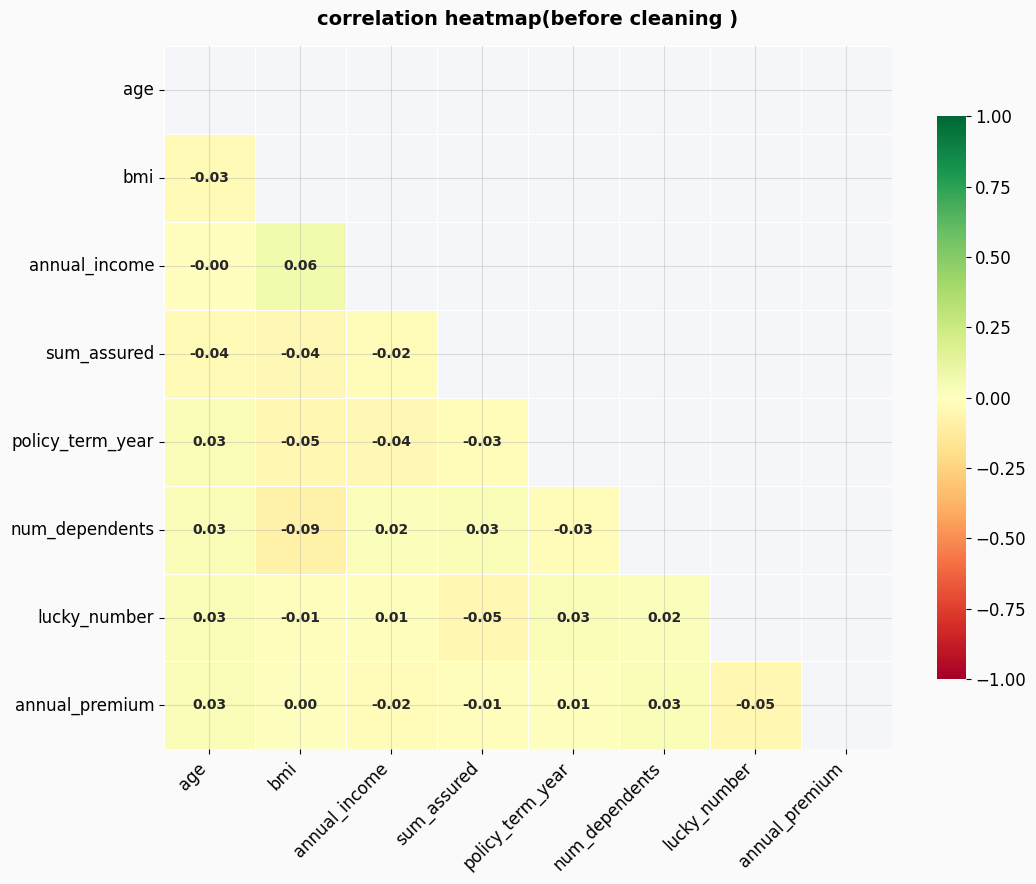

'
'correlation with annual_premium:
num_dependents      0.027
age                 0.026
policy_term_year    0.007
bmi                 0.004
sum_assured        -0.010
annual_income      -0.019
lucky_number       -0.048
Name: annual_premium, dtype: float64


In [58]:
num_df=df[['age','bmi','annual_income','sum_assured','policy_term_year','num_dependents','lucky_number','annual_premium']].dropna()
corr=num_df.corr()
fig,ax=plt.subplots(figsize=(11,9))
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='RdYlGn',center=0,vmin=-1,vmax=1,ax=ax,linewidths=0.5,
            linecolor='white',annot_kws={"size":10,"weight":"bold"},cbar_kws={"shrink":0.8})
ax.set_title('correlation heatmap(before cleaning )',fontsize=14,fontweight='bold',pad=15)
plt.xticks(rotation=45,ha='right');
plt.yticks(rotation=0)
plt.tight_layout();
plt.savefig('correlation_heatmap_before.png',dpi=120);
plt.show()
print("'\n'correlation with annual_premium:")
print(corr['annual_premium'].drop('annual_premium').sort_values(ascending=False).round(3))

In [59]:
df_clean=df.copy()
print("="*55)
print("5A:OUTLIER REMOVAL -IQR METHOD ON ANNUAL_INCOME")
print("="*55)
Q1=df_clean['annual_income'].quantile(0.25)
Q3=df_clean['annual_income'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

5A:OUTLIER REMOVAL -IQR METHOD ON ANNUAL_INCOME


In [65]:
print(f"Q1={Q1:.0f} Q3={Q3:.0f} IQR={IQR:.0f}")
print(f" acceptable range: [{lower_bound:.0f},{upper_bound:.0f}]")
outliers_mask=(df_clean['annual_income']<lower_bound) | (df_clean['annual_income']>upper_bound )
print(f" outlier rows detected: { outliers_mask.sum()}")
df_clean=df_clean[~outliers_mask].copy()
print(f" rows after outlier removal: {len(df_clean)}")
print("\n why iqr? a 70,00,000 income entry is statistically extreme for this population")
print("and would distort the line fit for typical policyholders.")



Q1=1047110 Q3=2947584 IQR=1900474
 acceptable range: [-1803601,5798296]
 outlier rows detected: 6
 rows after outlier removal: 594

 why iqr? a 70,00,000 income entry is statistically extreme for this population
and would distort the line fit for typical policyholders.


NOW WE WILL FILL MISSING VALUES IN THE BELOW CODE

In [70]:
print("="*50)
print("5B:FILL MISSING VALUES")
print("="*50)
for col in ['bmi','annual_income']:
  median_val = df_clean[col].median()
  missing_count=df_clean[col].isna().sum()
  df_clean[col]=df_clean[col].fillna(median_val)
  print(f"'{col}:filled {missing_count} NaN with median={median_val:.2f}")
mode_val=df_clean['medical_history'].mode()[0]
missing_count=df_clean['medical_history'].isnull().sum()
df_clean['medical_history']=df_clean['medical_history'].fillna(mode_val)
print(f"'medical_history':filled{missing_count} NaN with mode='{mode_val}'")
print(f"\n TOTAL NaN remining : {df_clean.isnull().sum().sum()}")
print("\n why median for BMI/income/ mean is sensitive to skew ; median is stable,")
print("why mode for medical_history? most applicaions have 'None' , the most likely guess")

print("="*50)

5B:FILL MISSING VALUES
'bmi:filled 0 NaN with median=27.34
'annual_income:filled 0 NaN with median=1986001.00
'medical_history':filled0 NaN with mode='Minor'

 TOTAL NaN remining : 54

 why median for BMI/income/ mean is sensitive to skew ; median is stable,
why mode for medical_history? most applicaions have 'None' , the most likely guess


In [77]:
df_clean.isna().sum()

,0
age,0
bmi,0
annual_income,0
sum_assured,0
policy_term_year,0
num_dependents,0
smoker,9
medical_history,0
applicant_id,0
lucky_number,0


In [82]:
print("="*50)
print("5B:FILL MISSING VALUES")
print("="*50)
for col in ['age','sum_assured','policy_term_year','num_dependents','applicant_id','lucky_number','annual_premium']:
  median_val = df_clean[col].median()
  missing_count=df_clean[col].isna().sum()
  df_clean[col]=df_clean[col].fillna(median_val)
  print(f"'{col}:filled {missing_count} NaN with median={median_val:.2f}")
mode_val=df_clean['medical_history'].mode()[0]
missing_count=df_clean['medical_history'].isnull().sum()
df_clean['medical_history']=df_clean['medical_history'].fillna(mode_val)
print(f"'medical_history':filled{missing_count} NaN with mode='{mode_val}'")
print(f"\n TOTAL NaN remining : {df_clean.isnull().sum().sum()}")
print("\n why median for BMI/income/ mean is sensitive to skew ; median is stable,")
print("why mode for medical_history? most applicaions have 'None' , the most likely guess")

print("="*50)

5B:FILL MISSING VALUES
'age:filled 0 NaN with median=43.00
'sum_assured:filled 0 NaN with median=1500000.00
'policy_term_year:filled 0 NaN with median=15.00
'num_dependents:filled 0 NaN with median=3.00
'applicant_id:filled 0 NaN with median=100295.50
'lucky_number:filled 0 NaN with median=48.00
'annual_premium:filled 0 NaN with median=2397.45
'medical_history':filled0 NaN with mode='Minor'

 TOTAL NaN remining : 0

 why median for BMI/income/ mean is sensitive to skew ; median is stable,
why mode for medical_history? most applicaions have 'None' , the most likely guess


In [79]:
df_clean[df_clean['smoker'].isna()]

,age,bmi,annual_income,sum_assured,policy_term_year,num_dependents,smoker,medical_history,applicant_id,lucky_number,annual_premium
59,31.0,25.271182,154483.0,1000000.0,20.0,1.0,NaN,Minor,100060.0,84.0,400832.459000
76,44.0,27.337433,1475727.0,500000.0,15.0,0.0,NaN,Minor,100077.0,51.0,630.000000
177,28.0,27.337495,2345951.0,750000.0,15.0,0.0,NaN,Minor,100178.0,13.0,1266.426501
198,43.0,29.358594,663360.0,3000000.0,25.0,5.0,NaN,Minor,100199.0,49.0,5870.170912
282,32.0,19.624574,1815355.0,5000000.0,20.0,0.0,NaN,Major,100283.0,83.0,8550.000000
363,61.0,35.232623,3049770.0,500000.0,10.0,5.0,NaN,Minor,100364.0,31.0,481131.851000
379,51.0,17.972973,1531068.0,2000000.0,10.0,4.0,NaN,Minor,100380.0,6.0,3990.000000
526,25.0,28.576873,1383752.0,3000000.0,15.0,5.0,NaN,Minor,100527.0,27.0,4987.226435
547,18.0,26.199913,3455334.0,3000000.0,10.0,0.0,NaN,Minor,100548.0,26.0,4553.996085


since there are missing values in smoker columns left , left fill it with the mode

In [80]:
mode_val = df_clean['smoker'].mode()[0]
df_clean['smoker'] = df_clean['smoker'].fillna(mode_val)

In [81]:
df_clean[df_clean['smoker'].isna()]

,age,bmi,annual_income,sum_assured,policy_term_year,num_dependents,smoker,medical_history,applicant_id,lucky_number,annual_premium


NOW THERE ARE NOOOOO NA VALUES AT ALL

In [83]:
#5C :DROP IRRELEVANT FEATURES
print("="*55)
print("5C:DROP IRRELEVANT FEATURES")
print("="*55)
drop_cols=['applicant_id','lucky_number']
print(f" dropping:{drop_cols}")
print("reason:correlation with annual premium=0(confirmed in heatup)")
print("an applicant id is just a label and lucky number is a random noise ")
print("no real insurer would use these as pricing factors")

df_clean.drop(columns=drop_cols,inplace=True)
print(f"\n final shape after cleaning:{df_clean.shape}")
print("remaining features:", df_clean.columns.tolist())

5C:DROP IRRELEVANT FEATURES
 dropping:['applicant_id', 'lucky_number']
reason:correlation with annual premium=0(confirmed in heatup)
an applicant id is just a label and lucky number is a random noise 
no real insurer would use these as pricing factors

 final shape after cleaning:(594, 9)
remaining features: ['age', 'bmi', 'annual_income', 'sum_assured', 'policy_term_year', 'num_dependents', 'smoker', 'medical_history', 'annual_premium']


In [84]:
df.sample(10)

,age,bmi,annual_income,sum_assured,policy_term_year,num_dependents,smoker,medical_history,applicant_id,lucky_number,annual_premium
416,60.0,34.625272,3849171.0,1000000.0,5.0,3.0,Yes,Minor,100417.0,89.0,2335.018294
454,30.0,27.867195,3115025.0,2000000.0,30.0,0.0,No,NaN,100455.0,9.0,2304.225168
515,22.0,38.765603,554348.0,5000000.0,25.0,6.0,no,Major,100516.0,22.0,8873.717034
322,28.0,25.565846,1057966.0,3000000.0,20.0,6.0,Yes,minor,100323.0,NaN,4978.009377
443,22.0,18.078416,2018638.0,1500000.0,20.0,6.0,No,Major,100444.0,83.0,1560.000000
74,50.0,23.268765,622603.0,3000000.0,15.0,3.0,No,Minor,100075.0,63.0,3960.000000
25,30.0,36.958043,3582337.0,1500000.0,30.0,3.0,Yes,NaN,100026.0,46.0,2821.342684
285,21.0,31.451518,2304944.0,1000000.0,5.0,7.0,Yes,NaN,100286.0,66.0,1644.675953
312,49.0,37.401662,2721126.0,1500000.0,5.0,0.0,No,NaN,100313.0,31.0,3906.722000
447,53.0,24.583944,1775250.0,5000000.0,20.0,1.0,Yes,none,100448.0,10.0,10125.000000


In [85]:
df_clean.sample(10)

,age,bmi,annual_income,sum_assured,policy_term_year,num_dependents,smoker,medical_history,annual_premium
94,18.0,36.339764,1125497.0,2000000.0,5.0,4.0,YES,Minor,3340.192920
485,43.0,35.537990,2819209.0,500000.0,10.0,0.0,No,Major,574.797548
292,51.0,26.085067,1995062.0,1000000.0,30.0,1.0,Yes,Major,2016.647087
177,28.0,27.337495,2345951.0,750000.0,15.0,0.0,Yes,Minor,1266.426501
190,62.0,21.783757,2802384.0,1000000.0,20.0,0.0,Yes,Minor,2160.000000
394,21.0,41.041644,2670867.0,500000.0,5.0,1.0,No,Minor,597.614467
51,25.0,41.199533,1248468.0,500000.0,10.0,3.0,No,Minor,621.667502
299,29.0,29.958731,3517827.0,750000.0,20.0,6.0,Yes,minor,1310.672153
377,49.0,29.046147,3811873.0,500000.0,5.0,1.0,Yes,Minor,1022.253394
147,43.0,20.191963,1316847.0,3000000.0,15.0,6.0,Yes,Minor,5625.000000


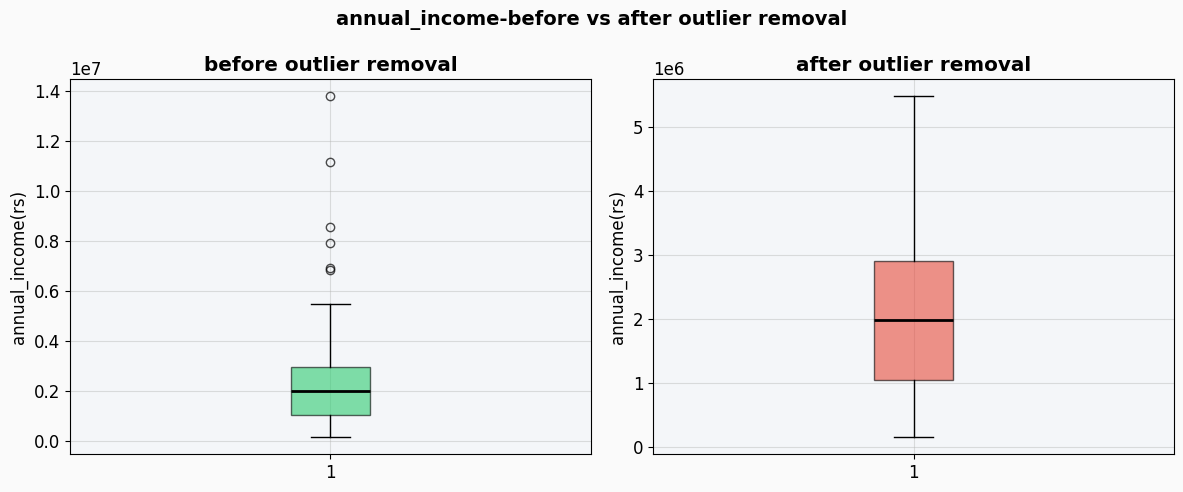

outliers removed.distribution is now realistic for the applicant pool.


In [89]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
fig.suptitle('annual_income-before vs after outlier removal',fontsize=14,fontweight='bold')
for ax,data,title,color in zip(
    axes,
    [df['annual_income'].dropna(),df_clean['annual_income'].dropna()],
    ['before outlier removal','after outlier removal'],
    ['#2ECC71','#E74C3C']
):
  ax.boxplot(data,patch_artist=True,
             boxprops=dict(facecolor=color,alpha=0.6),
             medianprops=dict(color='black',linewidth=2),
             flierprops=dict(marker='o',color='red',markersize=6,alpha=0.7))
  ax.set_title(title,fontweight='bold')
  ax.set_ylabel('annual_income($)')
plt.tight_layout()
plt.savefig('boxplot_before_after.png',dpi=120)
plt.show()
print("outliers removed.distribution is now realistic for the applicant pool.")

Before (left):

A handful of extreme outliers dominate the plot (circles above ~6M to 14M)
The bulk of the data gets squeezed into an unreadable box near zero
You can't see the actual distribution of normal cases

After (right):

Outliers removed (those extreme 6M-140M income values)
Now the realistic range is visible: median ~2M, spread from 0.5M to ~5.5M
The distribution is actually interpretable

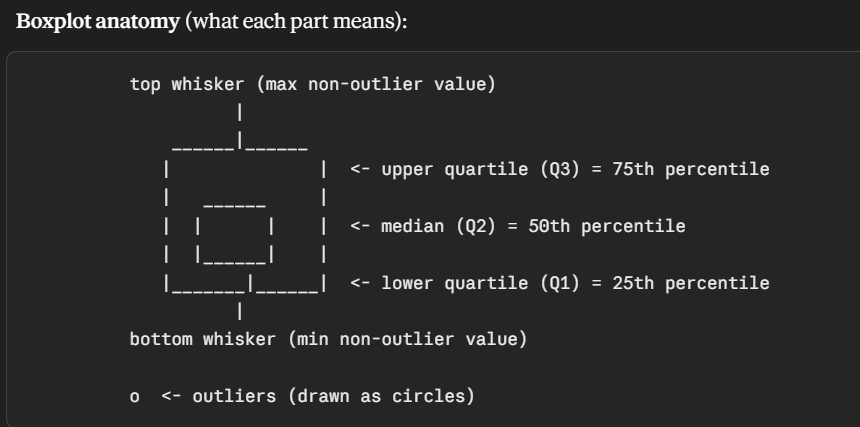

NOW WE DO
# FEATURE ENGINNERING



*   LABEL ENCODING- convert smoker and medical_history text to number
*   TRAIN-TEST SPLIT- 80% train/20% test , *done before scaling*

*   FEATURE SCALING-standardise numerical features (mean=0,std=1)
*   WHY SCALING???? SCALING PUTS EVERY FEATURE ON EQUAL FOOTING FOR THE MODEL




In [97]:
print('='*55)
print('STANDARDIZING SMOKER COLUMN')
print('='*55)

# Strip any whitespace from the 'smoker' column
df_clean['smoker'] = df_clean['smoker'].astype(str).str.strip()

# Create a mapping for standardization
smoker_mapping = {
    'N': 'No',
    'NO': 'No',
    'no': 'No',
    'Y': 'Yes',
    'YES': 'Yes',
    'yes': 'Yes'
}

# Apply the mapping. Values not in the mapping will remain unchanged (e.g., 'No', 'Yes')
df_clean['smoker'] = df_clean['smoker'].replace(smoker_mapping)

print(f"Unique values in 'smoker' after standardization: {df_clean['smoker'].unique()}")

STANDARDIZING SMOKER COLUMN
Unique values in 'smoker' after standardization: ['Yes' 'No']


In [99]:
print('='*55)
print('STANDARDIZING MEDICAL_HISTORY COLUMN')
print('='*55)

# Strip any whitespace and convert to lowercase for easier standardization
df_clean['medical_history'] = df_clean['medical_history'].astype(str).str.strip().str.lower()

# Create a mapping for standardization
medical_history_mapping = {
    'minor ': 'minor',
    ' major': 'major',
    'minor': 'Minor',
    'major': 'Major',
    'none': 'Unknown',
    '?': 'Unknown'
}

# Apply the mapping. Values not in the mapping (e.g., 'Minor', 'Major' already in correct case) will remain unchanged.
df_clean['medical_history'] = df_clean['medical_history'].replace(medical_history_mapping)

# Capitalize the first letter of 'Minor' and 'Major' if they exist after mapping
df_clean['medical_history'] = df_clean['medical_history'].apply(lambda x: x.capitalize() if x in ['minor', 'major'] else x)

print(f"Unique values in 'medical_history' after standardization: {df_clean['medical_history'].unique()}")

STANDARDIZING MEDICAL_HISTORY COLUMN
Unique values in 'medical_history' after standardization: ['Minor' 'Major' 'Unknown']


In [100]:
df_model=df_clean.copy()
print("="*55)
print("LABEL ENCODING")
print("="*55)
le=LabelEncoder()
for col in ['smoker','medical_history']:
  original=sorted(df_model[col].unique())
  df_model[col]=le.fit_transform(df_model[col])
  encoded=sorted(df_model[col].unique())
  print(f" '{col}':{original}->'{encoded}")
print("\n sklearn's linearregression requires numeric inputs only")

LABEL ENCODING
 'smoker':['No', 'Yes']->'[np.int64(0), np.int64(1)]
 'medical_history':['Major', 'Minor', 'Unknown']->'[np.int64(0), np.int64(1), np.int64(2)]

 sklearn's linearregression requires numeric inputs only


In [104]:
print("="*55)
print('train/test split (80%/20%)')
print("="*55)
x=df_model.drop(columns='annual_premium')
y=df_model['annual_premium']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f"training samples:{x_train.shape[0]}")
print(f"testing samples:{x_test.shape[0]}")
print(f"NaN in X-train:{x_train.isnull().sum().sum()} <- must be 0 before scaling")
print("\n why split before scaling? scaling on the full dataset would leak")
print("test-set statistics into the training process (data leakage).")


train/test split (80%/20%)
training samples:475
testing samples:119
NaN in X-train:0 <- must be 0 before scaling

 why split before scaling? scaling on the full dataset would leak
test-set statistics into the training process (data leakage).


In [106]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print(f"sum_assured-raw mean: {x_train['sum_assured'].mean():,.1f}")
print(f"sum_assured-scaled mean: {x_train_scaled[:,3].mean():,.8f} (=0)")
print(f"sum_assured-scaled std: {x_train_scaled[:,3].std():,.8f} (=1)")
print("\n all features scaled-fair playing field for the model")

sum_assured-raw mean: 1,983,157.9
sum_assured-scaled mean: 0.00000000 (=0)
sum_assured-scaled std: 1.00000000 (=1)

 all features scaled-fair playing field for the model
